In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
event1='fixed_best_final'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [5]:
cluster_files

['superclust_clusters_500_fixed_best_final.pkl']

In [6]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_fixed_best_final.pkl
dict_keys(['total', 'inc', 'dec', 'flat', 'non'])
CPU times: user 267 µs, sys: 2.49 ms, total: 2.75 ms
Wall time: 52.1 ms


In [7]:
label_files

['supercluster_labels_total_500.npy']

In [8]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 1.35 ms, sys: 19.1 ms, total: 20.4 ms
Wall time: 136 ms


In [9]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [10]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [11]:
giant_total_anat.shape

(314, 146, 91)

(-0.5, 313.5, 145.5, -0.5)

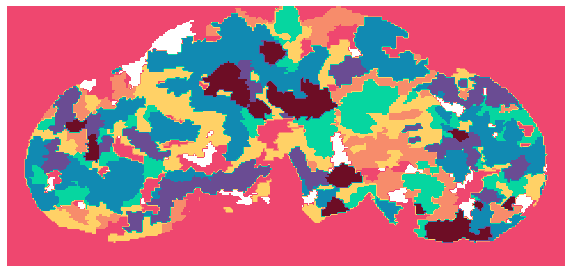

In [12]:
z=33
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(giant_total_anat[...,30:34],axis=-1).T, cmap=cmap_rainbow)
plt.axis('off')
# plt.savefig(os.path.join(save_dir,f'superclust_ex.png'), dpi=300, bbox_inches='tight')

In [13]:
sizes=[]
for i in range(500):
    size=np.count_nonzero(np.isin(giant_total_anat,i))
    sizes.append(size)

In [14]:
np.where(sizes==np.max(sizes))

(array([71]),)

In [15]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

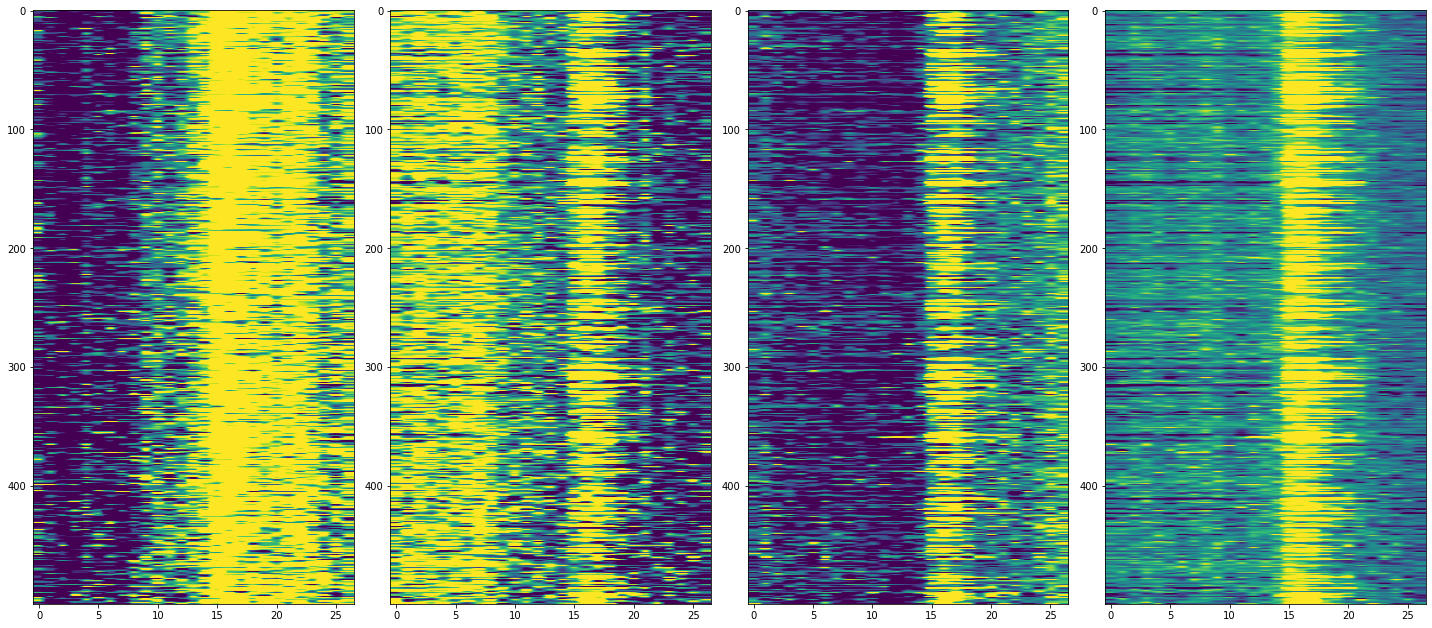

In [16]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.1
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,4,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'][:,14:41], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'][:,14:41],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'][:,14:41],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['non'][:,14:41],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [17]:
superclust_dict_trim={}
for behavior in five_sec:
#     print(behavior)
    signals_total=five_sec[behavior][:,14:41]
    superclust_dict_trim[behavior]=signals_total
    
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

total
inc
dec
flat
non


In [18]:
superclust_dict_trim['inc'].shape

(500, 27)

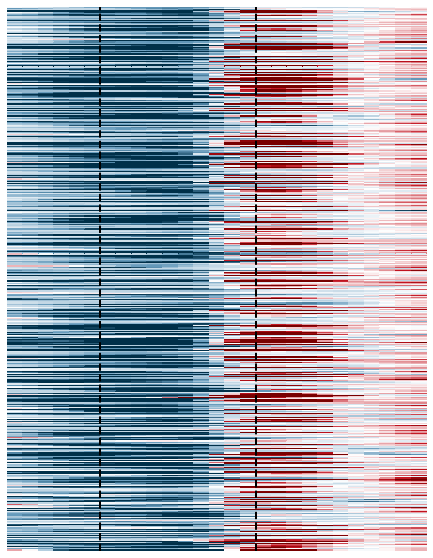

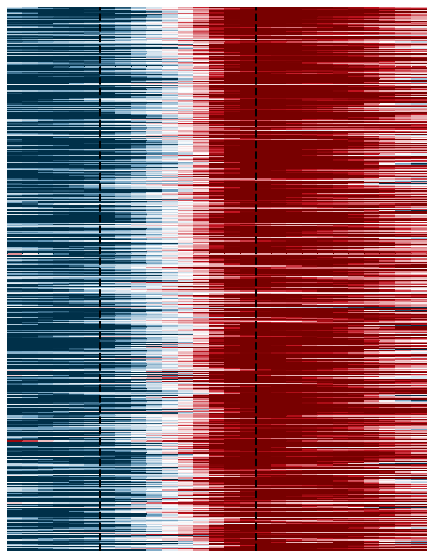

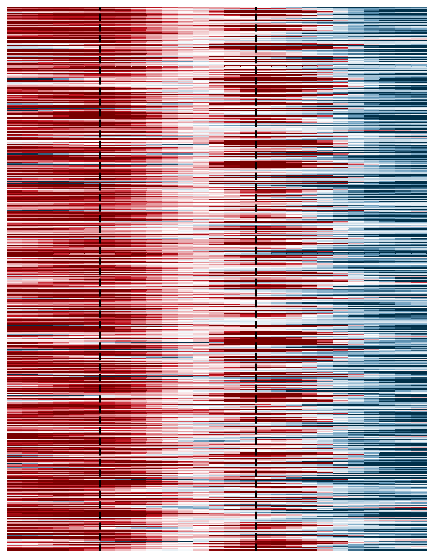

In [27]:
ax_ap=0.07
vmax=0.01
vmin=-0.01
plot_dict=superclust_dict_trim
fig,axs=plt.subplots(figsize=(10,10))
sns.heatmap(gaussian_filter1d(plot_dict['flat'],sigma=2), cmap=cmap_personal, ax=axs, square=False,  
            center=0, vmax=vmax, vmin=vmin,yticklabels=False,xticklabels=False, cbar=False)
axs.set_aspect(ax_ap)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_flat_{event1}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_flat_{event1}.png'), dpi=300, bbox_inches='tight')
fig,axs=plt.subplots(figsize=(10,10))
sns.heatmap(gaussian_filter1d(plot_dict['inc'], sigma=2), cmap=cmap_personal,  ax=axs,square=False,  
            center=0, vmax=vmax, vmin=vmin,yticklabels=False, xticklabels=False, cbar=False)
axs.set_aspect(ax_ap)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_inc_{event1}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_inc_{event1}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
fig,axs=plt.subplots(figsize=(10,10))
sns.heatmap(gaussian_filter1d(plot_dict['dec'],sigma=2), cmap=cmap_personal, ax=axs,square=False,   
            center=0, vmax=vmax, vmin=vmin,yticklabels=False,xticklabels=False,
            cbar=False, cbar_kws={'orientation': 'horizontal', 'shrink':0.7, 'ticks': [],"pad": 0.01})
axs.set_aspect(ax_ap)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_dec_{event1}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_dec_{event1}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
# fig,axs=plt.subplots(figsize=(10,10))
# sns.heatmap(gaussian_filter1d(plot_dict['non'],sigma=2), cmap=cmap_personal, ax=axs,square=False,   
#             center=0, vmax=vmax, vmin=vmin,yticklabels=False,xticklabels=False, 
#             cbar=False, cbar_kws={'orientation': 'horizontal', 'shrink':0.7, 'ticks': [],"pad": 0.01})
# axs.set_aspect(ax_ap)
# axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
# axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'superclust_heatmap_non_{event1}.png'), dpi=300, bbox_inches='tight')
# axs[0].imshow(gaussian_filter1d(superclust_dict_z['flat'], sigma=1.5),vmax=vmax, vmin=vmin, cmap=cmap_personal)
# plt.tight_layout()

In [28]:
plot_dict['inc'].shape

(500, 27)

In [29]:
roi_atlas = brainsss.load_roi_atlas()

explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [36]:
full_res=[]
be='inc'
n_clusters=500
cluster_brain=plot_dict[be]
brain=cluster_brain.T
cluster_labels=giant_total_labels.T
n_tp = brain.shape[0]
n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
full_res=np.asarray(colored_by_betas)

In [37]:
np.shape(full_res)

(27, 314, 146, 91)

In [38]:
tp=3
brain=full_res
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[tp][:,:,::-1]
vmax = 0.03 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

(-0.5, 499.5, 329.5, -0.5)

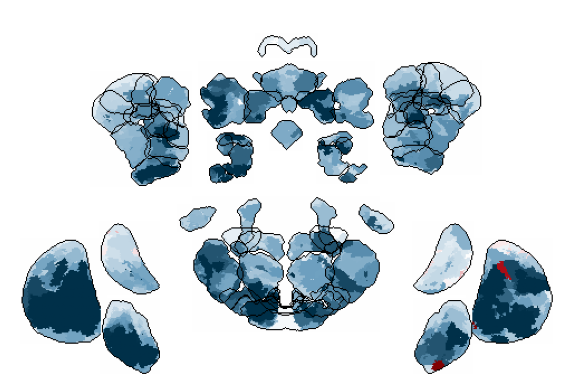

In [39]:
plt.subplots(figsize=(10,10))
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.savefig(os.path.join(save_dir,f'superclust_explode_{tp}_{be}_{event1}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'superclust_explode_{tp}_{be}_{event1}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)



In [ ]:
intervals=np.asarray([[0,7],[12,19]])

In [ ]:
# superclust_dict_z[behave].shape

In [ ]:
downsampled_superclust_dict={}
clust_dict=superclust_dict
for behave in clust_dict:
    cluster_dict=np.asarray(clust_dict[behave])
    downsampled_superclust=[]
    for interval in intervals:
        start=interval[0]
        end=interval[1]
#         print(start-end)
        avg_time=np.mean(cluster_dict[:,start:end],axis=-1)
        downsampled_superclust.append(avg_time)
        start=end
    downsampled_superclust=np.asarray(downsampled_superclust).T
#     print(np.shape(downsampled_superclust))
    downsampled_superclust_dict[behave]=downsampled_superclust

In [ ]:
# bin_size=5
# downsampled_superclust_dict={}
# clust_dict=superclust_dict_z
# for behave in clust_dict:
#     num_bins=int((clust_dict[behave].shape[-1]+1)/bin_size)
#     start=0
#     downsampled_superclust=[]
#     for i in range(num_bins):
#         end=start+bin_size
# #         print(start,end)
#         avg_time=np.mean(clust_dict[behave][:,start:end],axis=-1)
#         downsampled_superclust.append(avg_time)
#         start=end
#     downsampled_superclust=np.asarray(downsampled_superclust).T
# #     print(np.shape(downsampled_superclust))
#     downsampled_superclust_dict[behave]=downsampled_superclust

In [ ]:
ax_ap=0.01
vmax=0.05
vmin=-0.05
fig,axs=plt.subplots(1,3,figsize=(10,10))
sns.heatmap(downsampled_superclust_dict['inc'], cmap=cmap_personal, ax=axs[0], square=False,  
            center=0, vmax=vmax, vmin=vmin,yticklabels=False, cbar=False)
sns.heatmap(downsampled_superclust_dict['dec'], cmap=cmap_personal, ax=axs[1], square=False,  
            center=0, vmax=vmax, vmin=vmin,yticklabels=False, cbar=False)
sns.heatmap(downsampled_superclust_dict['flat'], cmap=cmap_personal, ax=axs[2], square=False,  
            center=0, vmax=vmax, vmin=vmin,yticklabels=False, cbar=False)
cbar = fig.colorbar(axs[-1].collections[0], ax=axs, shrink=0.8)
cbar.set_label('f$_n$', rotation=270, labelpad=20)
# cbar.set_ticks([vmax, 0, vmin]) 
# Remove the black border
cbar.outline.set_visible(False)

In [ ]:
file_path=os.path.join(cluster_dir, 'individual_fly_superclusters_2bin.pkl')
with open(file_path, 'rb') as file:
        fly_superclust_dict = pickle.load(file)

In [ ]:
fly_num=[226,227,228,234,239,240,241,242,249,250]
for fn in fly_num:
    behave_dic=fly_superclust_dict['flat']
    if fn in list(behave_dic.keys()):
        print(np.count_nonzero(~np.isnan(behave_dic[fn][...,0])))

In [ ]:
fly_superclust_dict['inc'].keys()

In [ ]:
num_vox=[]
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        num_vox.append(count_vox)
max_val=np.max(num_vox)
print(max_val)

In [ ]:
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        if count_vox<max_val:
            pad_val=max_val-count_vox
#             print(pad_val)
            matrix=fly_superclust_dict[behave][fly]
            padded_matrix = np.pad(matrix, ((0, 0), (0, pad_val),(0,0)),'constant', constant_values=np.nan)
            fly_superclust_dict[behave][fly]=padded_matrix 

In [ ]:
%%time
anova_dict={}
for behave in fly_superclust_dict:
    anova_dict[behave]={}
    avg_clusts=downsampled_superclust_dict[behave]
    individual_clusts=fly_superclust_dict[behave]
    for i,super_clust in enumerate(avg_clusts):
        anova_dict[behave][i]=[]
        for v, tp in enumerate(super_clust):
            ind_clus=[]
            for fly in individual_clusts:
                ind_clus_nan=individual_clusts[fly][i,:,v]
#                 print(ind_clus_nan)
#                 if np.all(np.isnan(ind_clus_nan))==False:
                ind_clus=np.concatenate((ind_clus,ind_clus_nan))

            anova_dict[behave][i].append(np.asarray(ind_clus))
        anova_dict[behave][i]=np.asarray(anova_dict[behave][i])
#         print(np.shape(anova_dict[behave][i]))

In [ ]:
np.count_nonzero(~np.isnan(anova_dict['inc'][150]))

In [ ]:
np.count_nonzero(~np.isnan(anova_dict['flat'][499][-1]))

In [ ]:
dic=anova_dict
bs=np.asarray(list(dic.keys()))
combos=list(itertools.combinations(bs, 2))
print(combos)

In [ ]:
def columnwise_mannwhitney(a, b):
    """
    Performs Mann-Whitney U test on each column separately
    a, b: arrays of shape (n_samples, n_features)
    Returns: arrays of statistics and p-values for each column
    """
    a = np.array(a)
    b = np.array(b)
    
    n_cols = a.shape[1]
    stats = []
    p_vals = []
    
    for col in range(n_cols):
        # Get data for this column
        a_col = a[:, col]
        b_col = b[:, col]
        
        # Remove NaNs
        a_clean = a_col[~np.isnan(a_col)]
        b_clean = b_col[~np.isnan(b_col)]
        
        if len(a_clean) < 1 or len(b_clean) < 1:
            stats.append(np.nan)
            p_vals.append(np.nan)
        else:
            try:
                stat, p_val = scipy.stats.mannwhitneyu(a_clean, b_clean)
                stats.append(stat)
                p_vals.append(p_val)
            except:
                stats.append(np.nan)
                p_vals.append(np.nan)
    
    return np.array(stats), np.array(p_vals)

In [ ]:
pval_dict={}
for c in combos:
    b_1=c[0]
    b_2=c[1]
    new_key=f'{b_1}_vs_{b_2}'
    temp=[]
    for clust in range(500):
        a=np.moveaxis(anova_dict[b_1][clust],0,-1)
#         print(np.shape(a))
        b=np.moveaxis(anova_dict[b_2][clust],0,-1)
#         print(np.shape(b))
#         tstat,p_val=scipy.stats.ttest_ind(a,b,axis=-1,nan_policy='omit')
        stat,p_val=columnwise_mannwhitney(a,b)
#         print(p_val)
        temp.append(list(p_val))
    pval_dict[new_key]=temp

In [ ]:
pval_dict.keys()

In [ ]:
pval_correct_dict={}
for key in pval_dict:
    pval_flat=np.asarray(pval_dict[key]).flatten()
    rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(pval_flat, alpha=0.01, method='bonferroni')
    pval_correct=p_corrected.reshape(*np.shape(pval_dict[key]))
    pval_correct_dict[key]=pval_correct

In [ ]:
k='inc_vs_flat'
# custom_labels = [''] * len(pval_correct_dict[k])  # Start with all empty strings
# custom_labels[281] = 'Here!!!'  # Set label at desired position

In [ ]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
sns.heatmap(pval_correct_dict[k], 
            cmap='inferno_r', 
            ax=ax,yticklabels=False, cbar=False,
            xticklabels=['Before','During'],vmax=0.01)
cbar = fig.colorbar(ax.collections[0], ax=ax)
cbar.set_label('p-val', rotation=270, labelpad=20)
cbar.outline.set_visible(False)
# ax.axhline(y=281,ls='--', color='g', lw=2)
# cbar.set_ticks([vmax, 0, vmin]) 
# ax.axhline(y=379, color='w', lw=2)
# plt.savefig(os.path.join(save_dir,f'p_vals_{b_1}_{b_2}.png'), dpi=300, bbox_inches='tight')

In [ ]:
best_clus_dict={}
for ki in pval_correct_dict:
    print(ki)
    best_clus=[]
    for i,clus in enumerate(pval_correct_dict[ki]):
        if clus[0]<0.01:
            best_clus.append(i)
    print(best_clus)
    print(len(best_clus))
    best_clus_dict[ki]=best_clus

In [ ]:
# np.asarray(list(best_clus_dict.values())).shape
best_total=[list(best_clus_dict.values())[0], list(best_clus_dict.values())[1],list(best_clus_dict.values())[2]]
common_values =reduce(np.intersect1d, best_total)
# common_values_2 = np.intersect1d(list(best_clus_dict.values())[0], list(best_clus_dict.values())[2])
# common_values_3 = np.intersect1d(list(best_clus_dict.values())[1], list(best_clus_dict.values())[2])

In [ ]:
common_values

In [ ]:
comp='inc_vs_flat'
clusters_4_look=np.asarray(pval_correct_dict[comp][best_clus_dict[comp]])
clusters_4_look=np.asarray(pval_correct_dict[comp][common_values])
# sort=np.sort(clusters_4_look)
# sorted_look=clusters_4_look[sort]
print(clusters_4_look.shape)
# print(common_values_2)
# print(common_values_3)

In [ ]:
pval_correct_dict[b].shape

In [ ]:
b='inc_vs_flat'
look=pval_correct_dict[b][:,0]
fig, ax = plt.subplots(figsize=(20, 10))
ax.hist(look[look<0.01], bins=100);
# ax.set_xlim(0,0.01)

In [ ]:
behavior_colors={
    'inc': '#9400D3',
    'dec': '#727272',
    'flat': '#000000'
}

In [ ]:
def plot_cluster_traces(clusters_4_look,clust_dict=None, z=False, secondary=None):
    fig_shape=int(np.ceil(np.sqrt(len(clusters_4_look))))
    # print(clusters_4_look.shape)
    # print(fig_shape)
    if len(clusters_4_look)>1:
        if len(clusters_4_look)==2:
            fig,axs=plt.subplots(1,2,figsize=(10,5))
        else:
            fig,axs=plt.subplots(fig_shape,fig_shape,figsize=(10,10))
            axs=axs.flatten()
        for behave in clust_dict:
            for ind in range(clusters_4_look.size):
                clus=clusters_4_look[ind]
        #         print(clus)
                if clust_dict[behave][clus,:].shape[0]>30:
                    start=15;end=40
                else:
                    start=0;end=-1
                axs[ind].plot(clust_dict[behave][clus,start:end],color=behavior_colors[behave], label=behave)
                if z:
                    axs[ind].set_ylim(-2,3.5)
                else:
                    axs[ind].set_ylim(-0.05,0.1)
                axs[ind].set_xticks([])
                axs[ind].set_yticks([])
                axs[ind].set_title(clus,fontsize=10)
                x1=6;x2=16
                axs[ind].axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
                axs[ind].axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
                axs[ind].spines['top'].set_visible(False)
                axs[ind].spines['right'].set_visible(False)
                axs[ind].spines['bottom'].set_visible(False)
                axs[ind].spines['left'].set_visible(False)
                if secondary is not None:
                    axs[ind].set_xlabel(secondary[ind])
        plt.tight_layout() 
    else:
        fig,axs=plt.subplots(figsize=(10,10))
        for behave in clust_dict:
            clus=clusters_4_look[0]
    #         print(clust_dict[behave][clus,:].shape)
            if clust_dict[behave][clus,:].shape[0]>30:
                start=15;end=40
            else:
                start=0;end=-1
            axs.plot(clust_dict[behave][clus,start:end],color=colors[behave], label=behave)
            if z:
                axs.set_ylim(-2,3.5)
            else:
                axs.set_ylim(-0.05,0.1)
            axs.set_xticks([])
    #         axs.set_yticks([])
            axs.set_title(clus,fontsize=10)
            x1=6;x2=16
            axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
            axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
            axs.spines['top'].set_visible(False)
            axs.spines['right'].set_visible(False)
            axs.spines['bottom'].set_visible(False)
            axs.spines['left'].set_visible(False)
            if secondary is not None:
                    axs.set_xlabel(secondary[ind])
    
    giant_labels_anat=giant_total_labels.reshape(314,146,91)
    labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clusters_4_look),giant_labels_anat,np.nan)
    # labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
    ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='spring')
    ax.axis('off');


In [ ]:
# clusters_4_look=np.arange(100,200)
comp='inc_vs_flat'
clusters_4_look=np.asarray(best_clus_dict[comp])
# clusters_4_look=np.asarray(common_values)
# plot_cluster_traces(clusters_4_look,superclust_dict, z=False)
# # plt.savefig(os.path.join(save_dir,f'time_trace_{comp}.png'), dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clusters_4_look),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_rainbow)
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'most_sig_clust.png'), dpi=300, bbox_inches='tight')

In [ ]:
data=anova_dict
rows = []
for category in data.keys():
    for cluster_num in data[category].keys():
#         if int(cluster_num) <= 100:
        array_2d =data[category][cluster_num]

        # For dimension 0
        for val in array_2d[0]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'before',
                'dff': val
            })

        # For dimension 1
        for val in array_2d[1]:
            rows.append({
                'cluster': cluster_num,
                'category': category,
                'time': 'during',
                'dff': val
            })

df = pd.DataFrame(rows)

In [ ]:
np.shape(best_clus_dict['inc_vs_flat'])

In [ ]:
# clusters_4_look=best_clus_dict['inc_vs_flat']
clusters_4_look=np.asarray([187,318])
df_filtered = df[df['cluster'].isin(clusters_4_look)]
df_before = df_filtered[df_filtered['time'] == 'before']
df_during = df_filtered[df_filtered['time'] == 'during']

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15, 10))
sns.violinplot(
    data=df_before,
    x='cluster',
    y='dff',
    hue='category',
    split=False,  # Set to True if you want split violins within categories
    palette='Blues',
    ax=ax1, 
    inner="quart"

)
ax1.set_title('Before',fontsize=20)

sns.violinplot(
    data=df_during,
    x='cluster',
    y='dff',
    hue='category',
    split=False,  # Set to True if you want split violins within categories
    palette='Reds',
    ax=ax2, 
    inner="quart"

)
ax2.set_title('During',fontsize=20)


In [ ]:
# def herarchy_clust(superclust,t):
#     cmat=np.corrcoef(superclust)
#     shape=np.shape(cmat)
#     clust_labels=np.arange(0,shape[0])
#     dist_matrix = 1 - cmat
#     linkage= sch.linkage(pdist(cmat),method='complete',metric='euclidean',optimal_ordering=True)
#     t=t
#     clusters = sch.fcluster(linkage, t=t, criterion='distance')
#     print(np.unique(clusters))
#     n_clusters=len(np.unique(clusters))
    
#     to_sort=superclust 
#     clustered={}
#     clus_num=list(np.unique(clusters))
#     for val in clus_num:
#         clustered[val]={}
#         for i in range(to_sort.shape[0]):
#             cluster_val=clusters[i]
#             if cluster_val==val:
#                 clustered[val][i]=to_sort[i,:]
#     temp_clustered_final={}
#     cluster_dict=clustered
#     for cluster in clustered:
#         cluster=cluster-1
#         temp_clustered_final[cluster]={}
#         sort_idx=np.argsort(np.mean(list(cluster_dict[cluster+1].values()), axis=1))
#         names=list(cluster_dict[cluster+1].keys())
#         for idx in sort_idx:
#             key=names[idx]
#             temp_clustered_final[cluster][key]=cluster_dict[cluster+1][key]
#     area_size=[]
#     for clust in temp_clustered_final:
#         area_size.append(len(temp_clustered_final[clust].keys()))
#     order=np.argsort(area_size)
#     h_clustered={}
#     for val in temp_clustered_final:
# #     for val in order:
#         c=temp_clustered_final[val]
#         for name in c:
#             h_clustered[name]=c[name]
#     return linkage, clusters, clustered, cmat, clust_labels, h_clustered, order

In [ ]:
# def plot_h_clustering(links,clusts,clustered,cmat,labels,h_clustered, order, color_map):
#     cmat=cmat
#     linkage=links
#     clusters=clusts
#     def get_color(k):
#         if k < len(cmat):
#             return color_map[(clusters[k] - 1) % len(color_map)]
#         else:
#             # For merges, get the color of the smaller cluster being merged
#             left = int(linkage[k - len(cmat), 0])
#             right = int(linkage[k - len(cmat), 1])
#             return get_color(left)  # You could also choose right, or blend the colors

#     def link_color_func(k):
#         if k < len(cmat):
#             return get_color(k)
#         else:
#             # Check if the merge is above the threshold
#             merge_height = linkage[k - len(cmat), 2]
#             if merge_height > t:
#                 return 'black'
#             else:
#                 return get_color(k)

#     fig,axs = plt.subplots(figsize=(3, 10))

#     sch.dendrogram(linkage, p=len(cmat), truncate_mode='lastp', ax=axs,
#                    color_threshold=t, orientation='left',labels=labels,link_color_func=link_color_func)
#     # sch.dendrogram(linkage, labels=list(avg_behave.keys()))
#     # plt.title('Hierarchical Clustering Based on Correlation')
#     axs.set_xticks([])
#     axs.spines['top'].set_visible(False)
#     axs.spines['right'].set_visible(False)
#     axs.spines['bottom'].set_visible(False)
#     axs.spines['left'].set_visible(False)
    
#     cmat_h=h_clustered
#     cmat_ht=np.corrcoef(list(cmat_h.values()))
#     fig,axs = plt.subplots(figsize=(10,10))
#     sns.heatmap(cmat_ht, cmap='YlGnBu', cbar=True, ax=axs, square=True, 
#                 cbar_kws={"shrink": 0.8},yticklabels=np.asarray(list(cmat_h.keys())),
#                xticklabels=np.asarray(list(cmat_h.keys())))
    
#     to_plot=h_clustered
#     clustered=clustered
#     vmax=1
#     vmin=-1
#     fig,axs=plt.subplots(figsize=(10,15))
#     sns.heatmap(list(to_plot.values()),yticklabels=[], cmap='PRGn_r', 
#                 cbar=False, ax=axs, center=0,
#                vmax=vmax,vmin=vmin)
#     superclust_size=clusters.shape[0]
#     total=0
#     axs.axhline(y=0, color=color_map[0], lw=4)
#     for cluss in clustered:
#         clus_size=np.shape(list(clustered[cluss].keys()))[0]
#         total+=clus_size
#         if total<superclust_size:
#             axs.axhline(y=(total), color=color_map[cluss], lw=4)

In [ ]:
clus_of_interest=np.asarray([187,318])

In [ ]:
plot_cluster_traces(clus_of_interest,superclust_dict_z, z=True)
# plt.savefig(os.path.join(save_dir,f'rep_clust.png'), dpi=300, bbox_inches='tight')

In [ ]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0', '#118AB2','#6A4C93']) # '#6d0d25'
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
# sns.heatmap(types, 
#             cmap=cmap_rainbow, 
#             ax=ax,yticklabels=False, cbar=True,
#             xticklabels=['Flat','Increase','Decrease'])
# cbar = fig.colorbar(ax.collections[0], ax=ax)
# cbar.set_label('p-val', rotation=270, labelpad=20)
# cbar.outline.set_visible(False)

In [ ]:
def toms_request(clusters,clust_dict, anova_dict, z=False,labels=None, colors=None):
    ##########################################################################################################
    ## MAKE TIME TRACES
    ##########################################################################################################
    fig,axs=plt.subplots(figsize=(10,10))
    for behave in clust_dict:
        clus=clusters[0]
#         print(clust_dict[behave][clus,:].shape)
        if clust_dict[behave][clus,:].shape[0]>30:
            start=15;end=40
        else:
            start=0;end=-1
        axs.plot(clust_dict[behave][clus,start:end],color=colors[behave], label=behave)
#         print(behave,colors[behave])
        if z:
            axs.set_ylim(-2,3.5)
        else:
            axs.set_ylim(-0.05,0.1)
        axs.set_xticks([])
#         axs.set_yticks([])
        axs.set_title(clus,fontsize=10)
        x1=6;x2=16
        axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
        axs.spines['top'].set_visible(False)
        axs.spines['right'].set_visible(False)
        axs.spines['bottom'].set_visible(False)
        axs.spines['left'].set_visible(False)
    ##########################################################################################################
    ## MAKE ANATOMICAL MAP
    ##########################################################################################################
    giant_labels_anat=labels.reshape(314,146,91)
    labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clusters),giant_labels_anat,np.nan)
    # labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
    ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='Blues_r')
    ax.axis('off');
    
    ##########################################################################################################
    ## MAKE VIOLIN PLOT
    ##########################################################################################################
    data=anova_dict
    rows = []
    for category in data.keys():
        for cluster_num in data[category].keys():
    #         if int(cluster_num) <= 100:
            array_2d =data[category][cluster_num]

            # For dimension 0
            for val in array_2d[0]:
                rows.append({
                    'cluster': cluster_num,
                    'category': category,
                    'time': 'before',
                    'dff': val
                })

            # For dimension 1
            for val in array_2d[1]:
                rows.append({
                    'cluster': cluster_num,
                    'category': category,
                    'time': 'during',
                    'dff': val
                })

    df = pd.DataFrame(rows)
    
    df_filtered = df[df['cluster'].isin(clusters)]
    df_before = df_filtered[df_filtered['time'] == 'before']
    df_during = df_filtered[df_filtered['time'] == 'during']
    fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15, 10))
    sns.violinplot(
        data=df_before,
        x='cluster',
        y='dff',
        hue='category',
        split=False,  # Set to True if you want split violins within categories
        palette='Blues',
        ax=ax1, 
        inner="quart"

    )
    ax1.set_title('Before',fontsize=20)

    sns.violinplot(
        data=df_during,
        x='cluster',
        y='dff',
        hue='category',
        split=False,  # Set to True if you want split violins within categories
        palette='Reds',
        ax=ax2, 
        inner="quart"

    )
    ax2.set_title('During',fontsize=20)
    
    ##########################################################################################################
    ## PRINT PVALS
    ##########################################################################################################
    dic=anova_dict
    bs=np.asarray(list(dic.keys()))
    combos=list(itertools.combinations(bs, 2))
    
    pval_dict={}
    for c in combos:
        b_1=c[0]
        b_2=c[1]
        new_key=f'{b_1}_vs_{b_2}'
        temp=[]
        for clust in clusters:
            a=np.moveaxis(anova_dict[b_1][clust],0,-1)
    #         print(np.shape(a))
            b=np.moveaxis(anova_dict[b_2][clust],0,-1)
    #         print(np.shape(b))
    #         tstat,p_val=scipy.stats.ttest_ind(a,b,axis=-1,nan_policy='omit')
            stat,p_val=columnwise_mannwhitney(a,b)
    #         print(p_val)
            temp.append(list(p_val))
        pval_dict[new_key]=temp
        
    pval_correct_dict={}
    for key in pval_dict:
        pval_flat=np.asarray(pval_dict[key]).flatten()
        rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(pval_flat, alpha=0.01, method='bonferroni')
        pval_correct=p_corrected.reshape(*np.shape(pval_dict[key]))
        pval_correct_dict[key]=pval_correct
    for combo in pval_correct_dict:    
        print(f'{combo}: before={pval_correct_dict[combo][0][0]}, during={pval_correct_dict[combo][0][1]}')

In [ ]:
np.asarray(best_clus_dict['inc_vs_flat'])

In [ ]:
pval_correct_dict['inc_vs_dec'].shape

In [ ]:
clus_list=np.asarray(best_clus_dict['inc_vs_flat'])
for clus in clus_list:
    print(clus)
    for combo in pval_correct_dict:
        print(f'{combo}: {pval_correct_dict[combo][clus][0]}')
    print('__________________________________________________________________')

In [ ]:
# %%time
toms_request([281],superclust_dict, anova_dict, z=False,labels=giant_total_labels,colors=behavior_colors)

In [ ]:
giant_superclust=[]
for i in range(superclust_dict_z['inc'].shape[0]):
    clust_behave=np.vstack((superclust_dict_z['inc'][i,:],superclust_dict_z['dec'][i,:],superclust_dict_z['flat'][i,:]))
    giant_superclust.append(clust_behave)
giant_superclust=np.vstack(giant_superclust)
print(giant_superclust.shape)

In [ ]:
data=gaussian_filter1d(giant_superclust,sigma=1)
# data=giant_superclust

inertias = []
ks = 20

for i in range(1,ks):
    kmeans = sklearn.cluster.KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
# plt.savefig(os.path.join(save_dir,f'k_elbow_smooth.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
n_clusters=6
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters)
kmeans.fit(data)
np.shape(kmeans.labels_)

In [ ]:
labels=kmeans.labels_
sort_array=np.argsort(labels)
k_clustered=data[sort_array]

In [ ]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93', '#6d0d25']) 
rainbow_color=rainbow_color[:n_clusters]
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [ ]:
to_plot=k_clustered
color_map=rainbow_color
clustered=np.unique(labels)
vmax=1
vmin=-1
fig,axs=plt.subplots(figsize=(10,15))
sns.heatmap(to_plot,yticklabels=[],xticklabels=[],
            cmap=cmap_personal, cbar=False, ax=axs, center=0,vmax=vmax,vmin=vmin)
superclust_size=np.shape(to_plot)[0]
total=0
axs.axhline(y=1500, color=color_map[-1], lw=10)
for cluss in clustered:
    clus_size=np.shape(labels[labels==cluss])[0]
    total+=clus_size
    if total<superclust_size:
        axs.axhline(y=(total), color=color_map[cluss], lw=4)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}clusters_smooth.png'), dpi=300, bbox_inches='tight')

In [ ]:
types=np.zeros((superclust_dict_z['inc'].shape[0], len(superclust_dict_z)))
for clus in clustered:
    clus_in=np.where(labels==clus)[0]
    remains=np.remainder(clus_in,3)
    which=np.full(*np.shape(remains),str)
    
    for i in range(len(superclust_dict_z)):
        if i==1:
            behave='dec'
        elif i==2:
            behave='flat'
        else:
            behave='inc'
        which[np.where(remains==i)]=behave
    for i,el in enumerate(clus_in):
        clus_name=int(np.ceil(el/3))-1
        behave=which[i]
        if behave=='flat':
            types[clus_name,0]=clus
        elif behave=='inc':
            types[clus_name,1]=clus
        else:
            types[clus_name,2]=clus

In [ ]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
# custom_ticks=np.arange(1,(n_clusters+1))
# sns.set(font_scale=1)
sns.heatmap(types, 
            cmap=cmap_rainbow, 
            ax=ax,yticklabels=False, cbar=True,
            xticklabels=['Flat','Increase','Decrease'], 
            cbar_kws={'ticks': [],"pad": 0.01})

# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}types_smooth.png'), dpi=300, bbox_inches='tight')

In [ ]:
labels

In [ ]:
stat_sig=best_clus_dict['inc_vs_flat']

In [ ]:
sig_best_clus={}
for cluster in range(n_clusters):
    print(cluster)
    sig_best_clus[cluster]=[]
    clusters_4_look=np.where(labels==cluster)[0]
    clusters_4_look=np.ceil(clusters_4_look/3).astype(int)
#     print(np.shape(clusters_4_look))
    uniques=np.unique(clusters_4_look)-1
    uniques[uniques==8]=uniques[-1]
#     print(np.shape(uniques))
    for clus in stat_sig:
        if clus in uniques:
            sig_best_clus[cluster].append(clus)
    sig_best_clus[cluster]=np.asarray(sig_best_clus[cluster])

In [ ]:
best_total=[sig_best_clus[5], sig_best_clus[3]]
common_values=reduce(np.intersect1d, best_total)

In [ ]:
common_values

In [ ]:
# cluster=3
plot_cluster_traces(common_values,superclust_dict_z, z=True)

In [ ]:
cluster=2
clusters_4_look=np.where(labels==cluster)[0]
clusters_4_look=np.ceil(clusters_4_look/3).astype(int)
print(np.shape(clusters_4_look))
uniques=np.unique(clusters_4_look)-1
uniques[uniques==8]=uniques[-1]
print(np.shape(uniques))
# uniques
plot_cluster_traces(uniques,superclust_dict_z, z=True)

In [ ]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [ ]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=True)#'hot')
    return explosion_map

In [ ]:
full_res_superclust={}
superclust=superclust_dict_z
n_clusters=500
for behave in superclust:
    cluster_brain=superclust[behave]
    brain=cluster_brain.T
    cluster_labels=giant_total_labels.T
    n_tp = brain.shape[0]
    n_clusters = brain.shape[1]
    brain_dims=[314,146,91]

    colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
    colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
    colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
    #     for cluster_num in range(n_clusters):
    #         cluster_mask = cluster_labels==cluster_num
    # #         print(np.shape(cluster_mask))
    #         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
    colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
    full_res_superclust[behave]=np.asarray(colored_by_betas)

In [ ]:

masked_nonan=np.where(np.isin(giant_labels_anat,uniques),brain, np.nan)
masked_nonan=np.nan_to_num(masked_nonan)
tp=15
vmax=5
during_i=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
tp=1
before_i=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)


In [ ]:
b='flat'
brain=full_res_superclust[b]
masked_nonan=np.where(np.isin(giant_labels_anat,common_values),brain, np.nan)
masked_nonan=np.nan_to_num(masked_nonan)
tp=15
vmax=5
during_f=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
tp=1
before_f=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)


In [ ]:
b='inc'
brain=full_res_superclust[b]
ax_as=1.5
fig,axs=plt.subplots(1,5,figsize=(50,50))
for i in range(5):
    masked_nonan=np.where(np.isin(giant_labels_anat,common_values),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    tp=i+1
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
    axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)


In [ ]:
b='flat'
brain=full_res_superclust[b]
ax_as=1.5
fig,axs=plt.subplots(1,5,figsize=(50,50))
for i in range(5):
    masked_nonan=np.where(np.isin(giant_labels_anat,common_values),brain, np.nan)
    masked_nonan=np.nan_to_num(masked_nonan)
    tp=i+1
    vmax=5
    temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,tp,cmap=cmap_personal)
    axs[i].imshow(temp[170:,:]) #this was made with cmap=hot
    axs[i].axis('off')
    axs[i].set_title(f'{tp}',fontsize=50)
    axs[i].set_aspect(ax_as)

In [ ]:
pca=PCA()

In [ ]:
%%time 
behave='inc'
pca_result = pca.fit_transform(superclust_dict_z[behave])
print(np.shape(pca_result))
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"First 5 PCs explain: {cumulative_variance[:5]*100}% of variance")

In [ ]:
# 1. Plot explained variance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(explained_variance_ratio[:10], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each PC')

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:10], 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance Explained')
plt.show()

# 2. Examine the principal components (loadings)
# These show which timepoints contribute most to each PC
s,e,b = 17,20,1
plt.figure(figsize=(15, 4))
for i,v in enumerate(np.arange(s,e,b)):
    plt.subplot(1, (e-s), i+1)
    plt.plot(pca.components_[v])
    plt.title(f'PC{v} Loadings\n({explained_variance_ratio[v]*100:.1f}% variance)')
    plt.xlabel('Timepoint')
    plt.ylabel('Loading')
    plt.ylim(-0.5,1)
plt.tight_layout()
plt.show()

In [ ]:
np.shape(pca.components_)

In [ ]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [ ]:
full_res_PCA=[]
n_clusters=500
cluster_brain=pca_result
brain=cluster_brain.T
cluster_labels=giant_total_labels.T
n_tp = brain.shape[0]
n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
full_res_PCA=np.asarray(colored_by_betas)

In [ ]:
np.shape(full_res_PCA)

In [ ]:
brain=full_res_PCA
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[0][:,:,::-1]
vmax = 5 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

In [ ]:
plt.subplots(figsize=(10,10))
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')